## 🎯 Project Objective

The objective of this project is to analyze the relationship between employee salary and years of work experience using **Simple Linear Regression (OLS)**. The goal is to quantify how much salary is expected to increase with each additional year of experience, evaluate whether this relationship is statistically significant, and assess how well experience alone explains salary variation. The project also validates key regression assumptions through residual.

### Import required libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, r2_score

### Load dataset

In [28]:
df = pd.read_csv("Salary_Data.csv")
df.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


### Dataset overview

In [29]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes


YearsExperience    0
Salary             0
dtype: int64

### Visual salary distribution

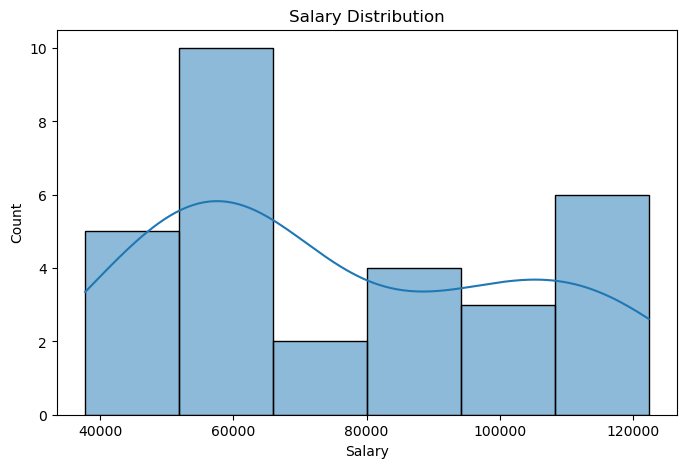

In [30]:
plt.figure(figsize=(8,5))
sns.histplot(df["Salary"], kde=True)
plt.title("Salary Distribution")
plt.savefig(
    r"C:\Users\Admin\OneDrive\Desktop\Python-1\02-data_analysis\02_linear regression_years_vs_experience\images\salary_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Scatter plot - relationship check

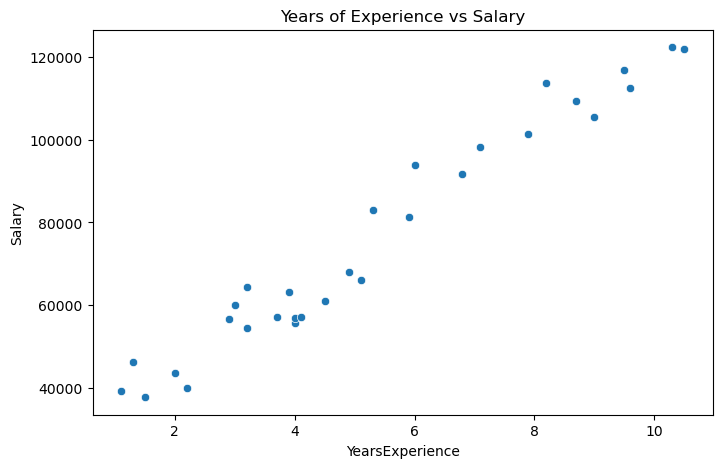

In [31]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="YearsExperience", y="Salary", data=df)
plt.title("Years of Experience vs Salary")
plt.savefig(
    r"C:\Users\Admin\OneDrive\Desktop\Python-1\02-data_analysis\02_linear regression_years_vs_experience\images\scatter_plot.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Correlation

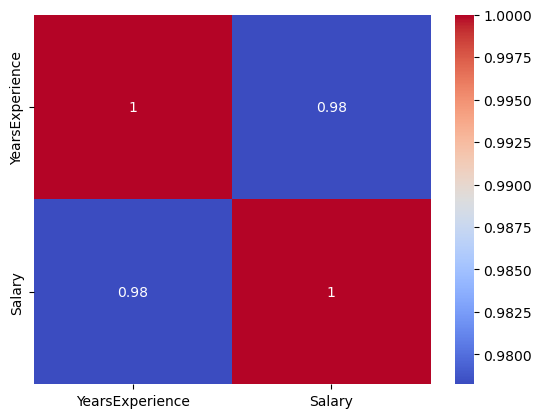

In [32]:
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.savefig(
    r"C:\Users\Admin\OneDrive\Desktop\Python-1\02-data_analysis\02_linear regression_years_vs_experience\images\correlation_plot.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Build OLS model

#### Define X & y

In [8]:
X = df[["YearsExperience"]]
y = df["Salary"]

#### Add constant

In [9]:
X_const = sm.add_constant(X)

#### Fit model

In [10]:
model = sm.OLS(y, X_const).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 Salary   R-squared:                       0.957
Model:                            OLS   Adj. R-squared:                  0.955
Method:                 Least Squares   F-statistic:                     622.5
Date:                Fri, 26 Dec 2025   Prob (F-statistic):           1.14e-20
Time:                        15:46:33   Log-Likelihood:                -301.44
No. Observations:                  30   AIC:                             606.9
Df Residuals:                      28   BIC:                             609.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const            2.579e+04   2273.053     11.347      0.000    2.11e+04    3.04e+04
YearsExperience  9449.9623    378.755     24.950      0.000    8674.119    1.02e+04
==============================================================================
Omnibus:                        2.140   Durbin-Watson:                   1.648
Prob(Omnibus):                  0.343   Jarque-Bera (JB):                1.569
Skew:                           0.363   Prob(JB):                        0.456
Kurtosis:                       2.147   Cond. No.                         13.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [20]:
model.params

const              25792.200199
YearsExperience     9449.962321
dtype: float64

### Plot regression line

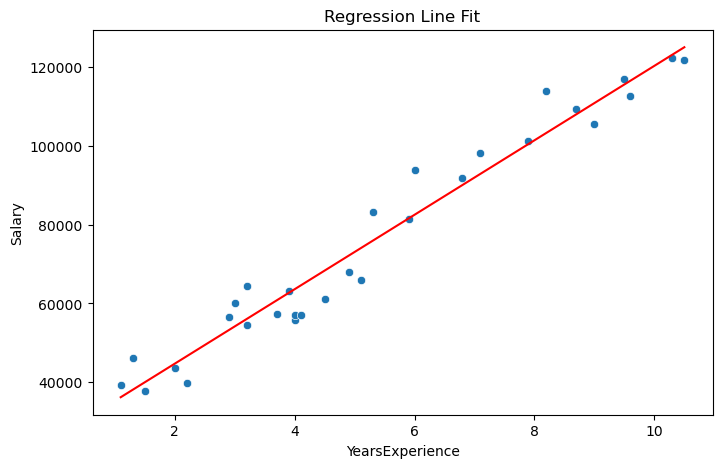

In [26]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="YearsExperience", y="Salary", data=df)

# regression line
sns.lineplot(
    x=df["YearsExperience"],
    y=model.predict(X_const),
    color="red"
)

plt.title("Regression Line Fit")
plt.savefig(
    r"C:\Users\Admin\OneDrive\Desktop\Python-1\02-data_analysis\02_linear regression_years_vs_experience\images\regression_fit_line.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Residual analysis

In [13]:
df["predicted"] = model.predict(X_const)
df["residuals"] = df["Salary"] - df["predicted"]

#### Residual distribution

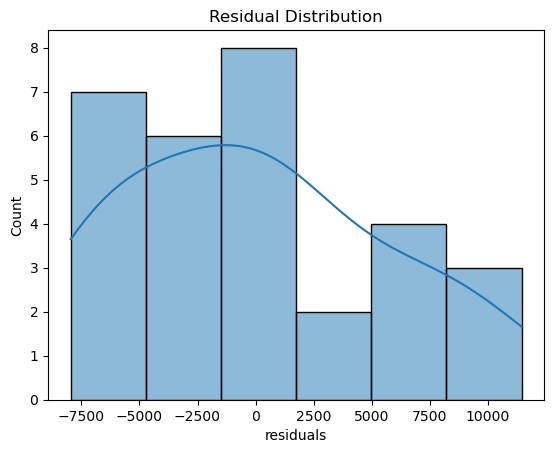

In [27]:
sns.histplot(df["residuals"], kde=True)
plt.title("Residual Distribution")
plt.savefig(
    r"C:\Users\Admin\OneDrive\Desktop\Python-1\02-data_analysis\02_linear regression_years_vs_experience\images\residual_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

#### Residual vs Fitted

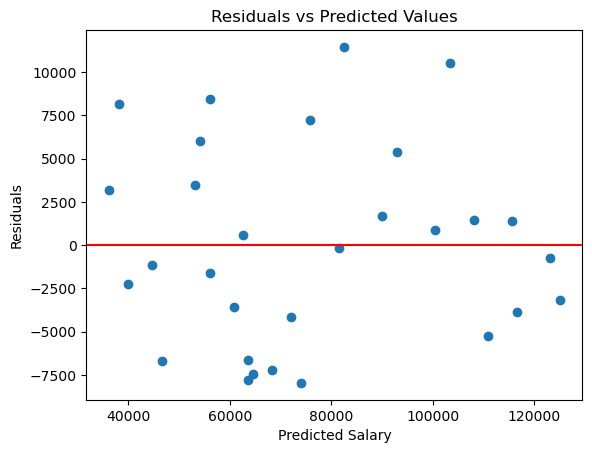

In [15]:
plt.scatter(df["predicted"], df["residuals"])
plt.axhline(0, color='red')
plt.title("Residuals vs Predicted Values")
plt.xlabel("Predicted Salary")
plt.ylabel("Residuals")
plt.show()

### Model performance metrix

In [18]:
rmse = np.sqrt(mean_squared_error(y, df["predicted"]))
r2 = r2_score(y, df["predicted"])

rmse, r2

(5592.043608760661, 0.9569566641435086)

### Key findings

- This OLS regression study shows a strong and statistically significant relationship between work experience and employee salary.
- On average, each additional year of experience contributes approximately ₹9,450 to expected salary, and around 95.7% of salary variation can be explained purely by experience. 
- The model fits well, satisfies key statistical assumptions, and highlights that most organizations follow a structured and experience-driven compensation policy, with only a few deviations. 
- This model can support HR budgeting, salary benchmarking, and workforce planning decisions.